# Photoswitching fingerprint fitting procedure

In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Reading the data

In [2]:
distances = [3, 5, 6, 8]
identifiers = [f"{distance}nm" for distance in distances]
bleaching_times_all = []
fingerprints_all = []

for _ in identifiers:
    fingerprints_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"D:\simulation_data\bleaching_fitting\4 fluorophores"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                break

for i, fingerprint in enumerate(fingerprints_all):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all[i] = fingerprint

### Fitting the data

##### Using the bleaching times and fitting a PDF

WARNING for line:             df = fun(x) - f0
 invalid value encountered in subtract 
WARNING for line:         return n/db/n.sum(), bin_edges
 invalid value encountered in divide 
WARNING for line:     model = total_pdf / (total_cdf[-1] - total_cdf[0])
 divide by zero encountered in divide 


Error in callback <function _draw_all_if_interactive at 0x00000168D338EE80> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

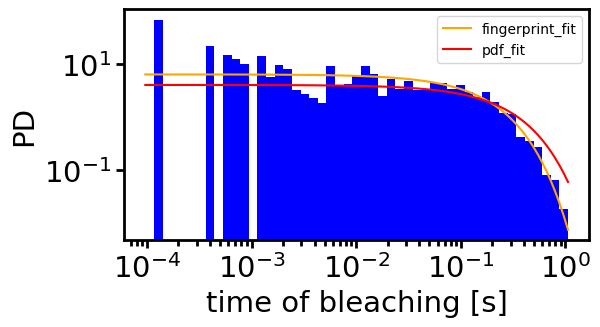

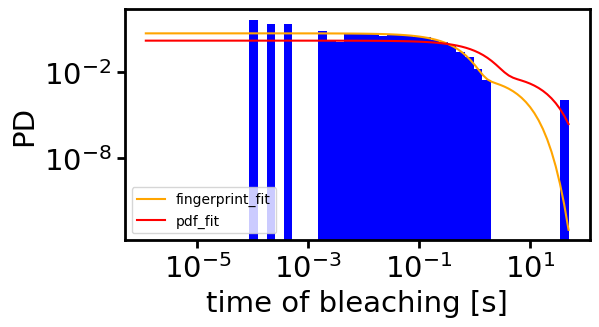

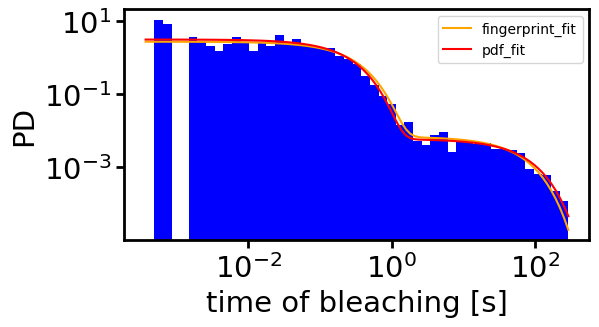

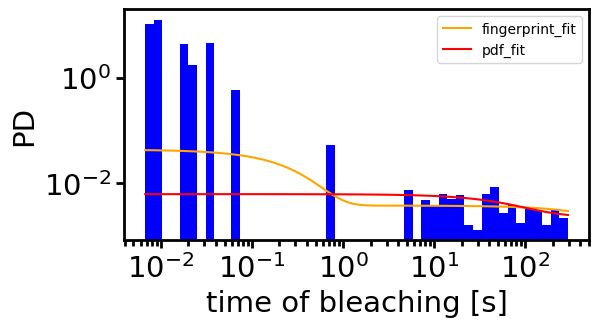

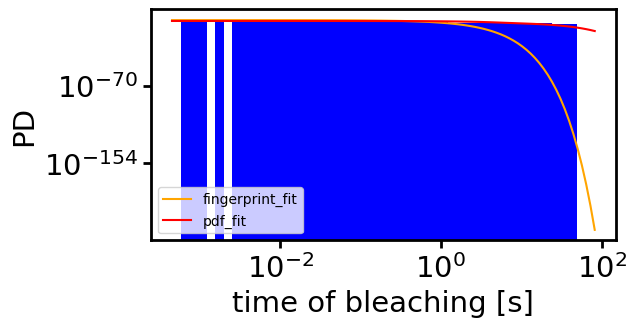

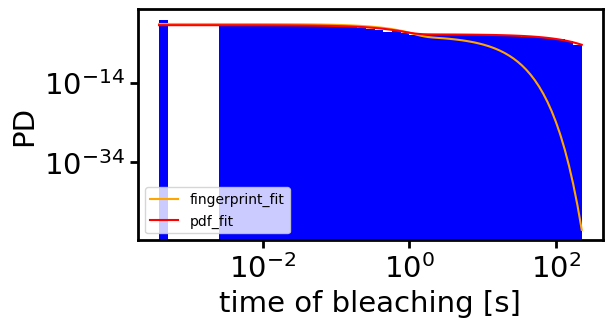

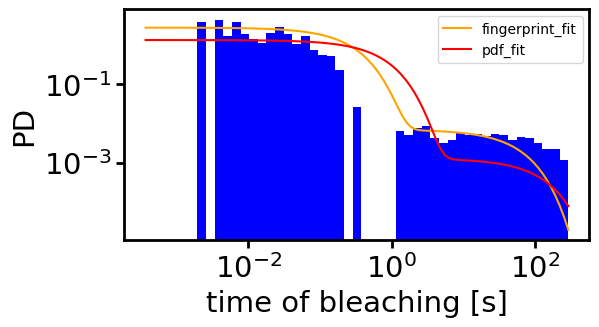

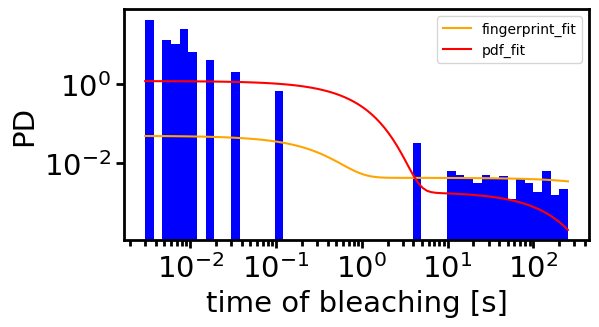

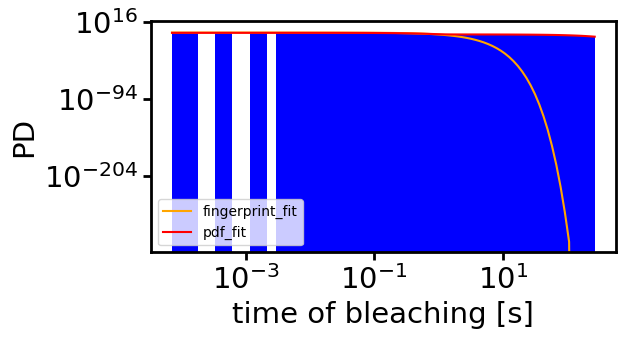

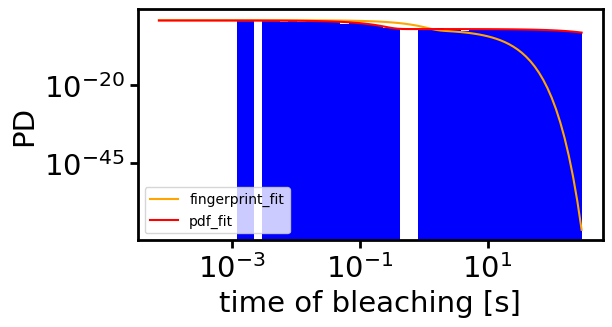

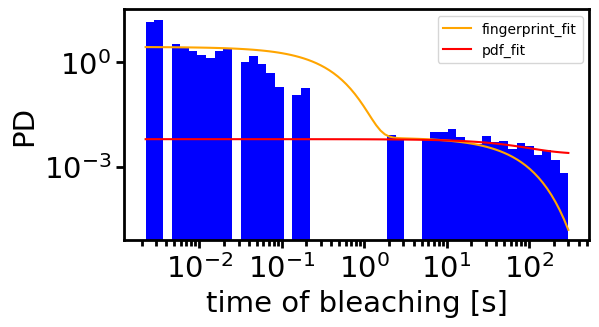

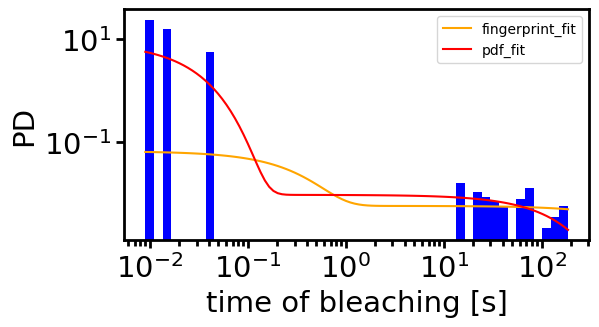

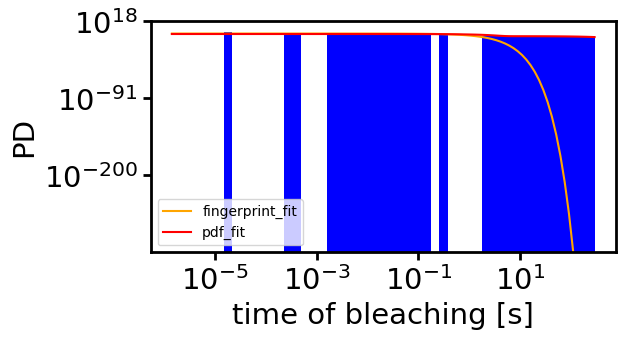

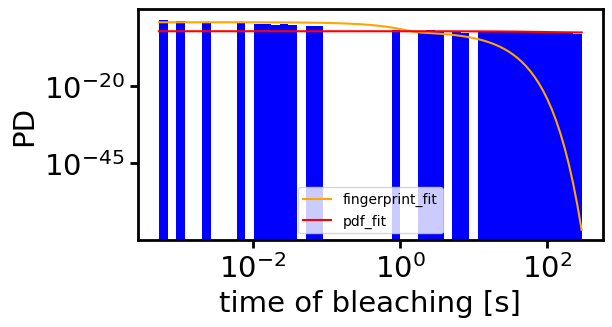

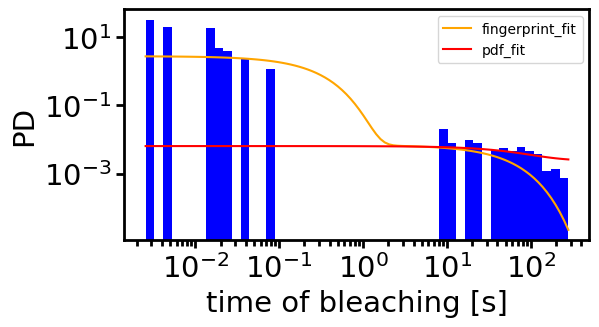

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 600x300 with 1 Axes>

In [72]:
parameters_all = []
for bleaching_times in bleaching_times_all:
    parameters, deltas = ro.get_global_bleaching_rates(bleaching_times)
    parameters_all.append(parameters)
    parameters2 = np.array([[1, 6.375, 5.259], [0.989, 5.155, 0.5], [0.664, 4.1, 2.04e-2], [0.0023, 3.722, 8.15e-4]])
    for param, param2, delt in zip(parameters, parameters2, deltas):
        pi, lambda1, lambda2 = param
        pi2, lambda12, lambda22 = param2
        bins = np.logspace(np.log10(np.min(delt)), np.log10(np.max(delt)), 50)
        x = np.logspace(np.log10(np.min(delt)), np.log10(np.max(delt)), 100)
        ax = fi.universal_figure(type_='hist', bins=bins, data=delt, density=True) 
        fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda12, lambda22, pi2)], color='orange', axes=ax[0],
                            label='fingerprint_fit')
        fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1, lambda2, pi)], 
                                type_='line', yscale='log', xscale='log', axes=ax[0],
                                xlabel='time of bleaching [s]', ylabel='PD', color='red', 
                                label='pdf_fit', legend=True)

### Approximation limits
The 2-exponential components approximation assumes two things: that there are only 2 components, and that they are exponentially distributed.
In the beginning, a *4-fluorophore* system has 4 fluorophores in their ON state. In contrast to a *1-fluorophore* system, this creates a **bias** not only because of the first ON state, but also the increased chance of a fluorophore entering the OFF state to be rescued due to the other 3 fluorophores still being in the ON state. Since there are so many possible energy transfer donors available, there is a high chance for the first fluorophore to bleach within this biased timeframe. \
Now that there are only 3 fluorophores left, if one enters the OFF state, the chance of being rescued before the other two entered the OFF state as well is smaller. The rescue chain may go on for a while, but eventuelly, all of them occupy the OFF state simultaneously (if the second bleaching event did not happen). Hence, there will be a (relatively) large time gap until the next bleaching event. At one point, one of the fluorophores will enter the ON state and has the ability to rescue the OFF state of one of the other two fluorophores. If a rescue happens, there is a even higher chance of rescueing the third. Now, the rescue chain may start again and there is a high chance of one of the fluorophores to bleach. Hence, the **non-biased** component may mainly be dictated by the *first OFF period (not OFF state) lifetime* of a 3 fluorophore system. \
Now there are only 2 fluorophores left. The chance of an ON state rescuing the other OFF state is much smaller, meaning rescuing chains being less likely. However, they can still happen. This is dictated mainly by the *OFF period lifetime of a 2-fluorophore system*. Times a factor that accounts for the higher rate due to rescue?

In [3]:
parameters_all_fit_pdf = []
for bl_times in bleaching_times_all:
    parameters_all_Fs = []
    for i in range(bl_times.shape[1]):
        pi, lambda1, lambda2 = dist.estimate_mixture_parameters(
            data=bl_times[:, i][~np.isnan(bl_times[:, i])],
            initial_guess=[0.5, 1, 1.1],
            bounds=([0, 1], [0, None], [0, None]),
            truncation_low=0,
            truncation_up=300,
            number_no_events=0,#np.count_nonzero(np.isnan(bl_times[:, i])),
            method='powell', 
        )
        parameters_all_Fs.append([pi, lambda1, lambda2])    
    parameters_all_fit_pdf.append(parameters_all_Fs)

WARNING for line:         return n/db/n.sum(), bin_edges
 invalid value encountered in divide 
WARNING for line:     model = total_pdf / (total_cdf[-1] - total_cdf[0])
 divide by zero encountered in divide 


Error in callback <function _draw_all_if_interactive at 0x00000243622B2E80> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

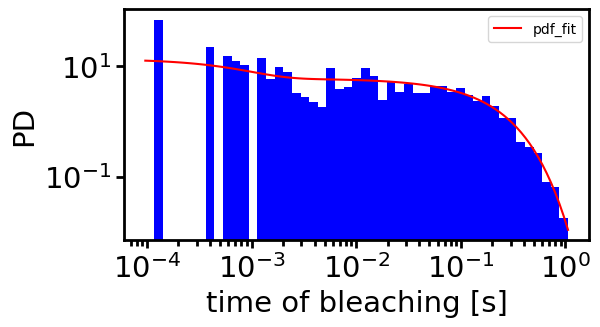

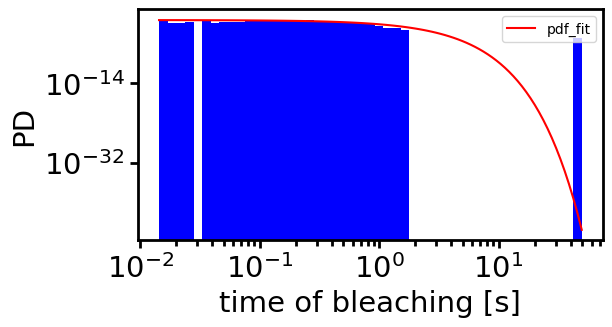

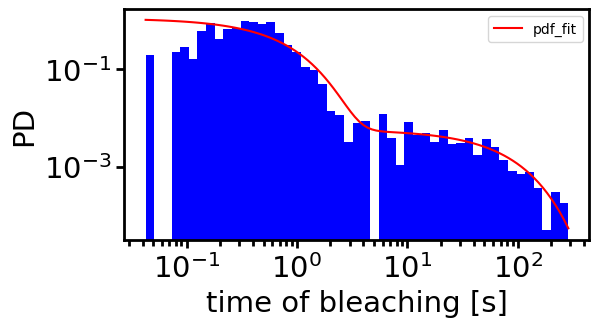

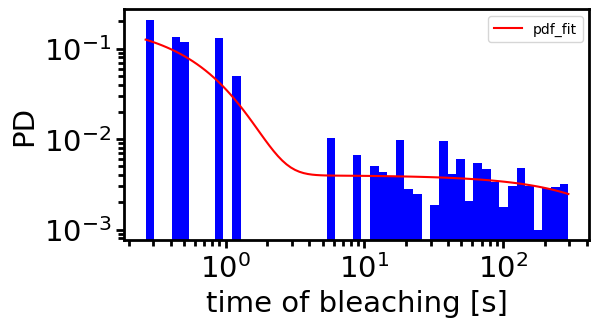

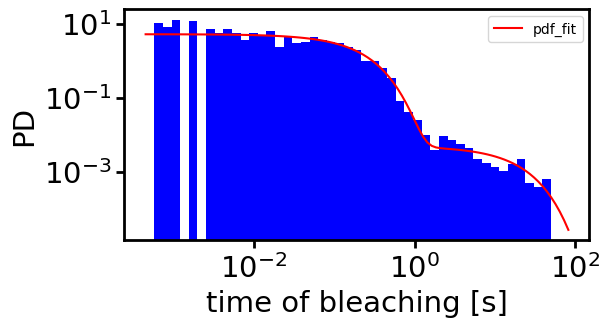

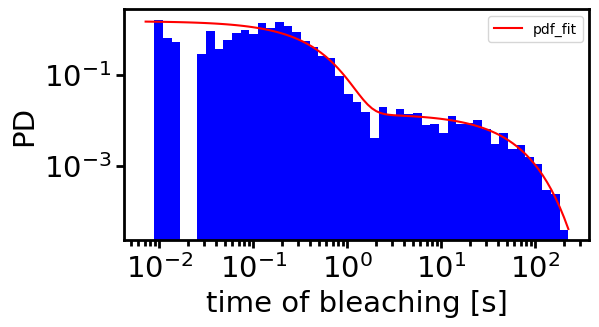

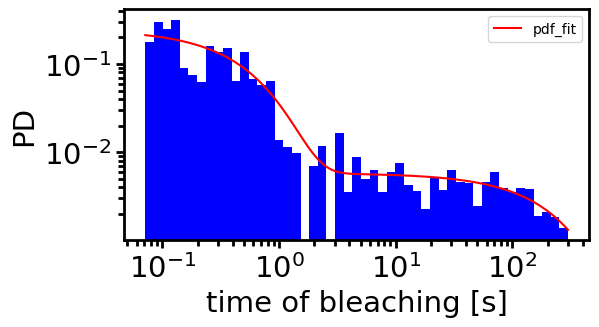

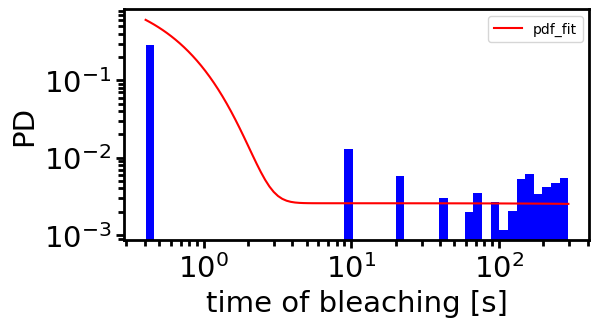

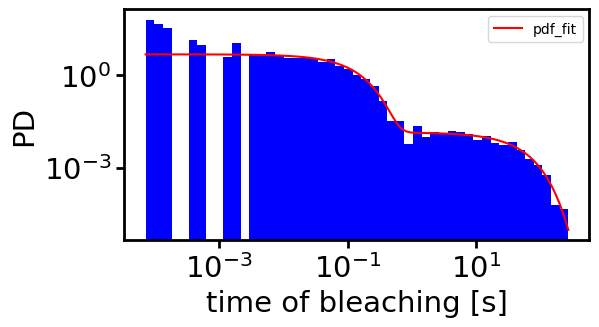

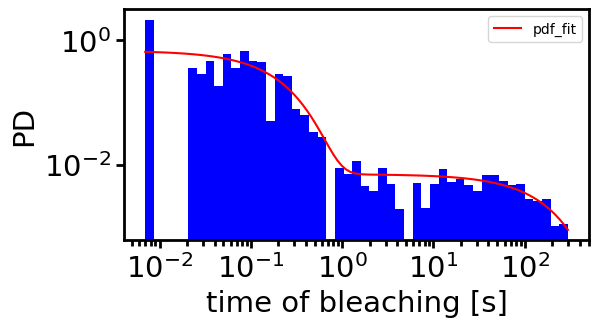

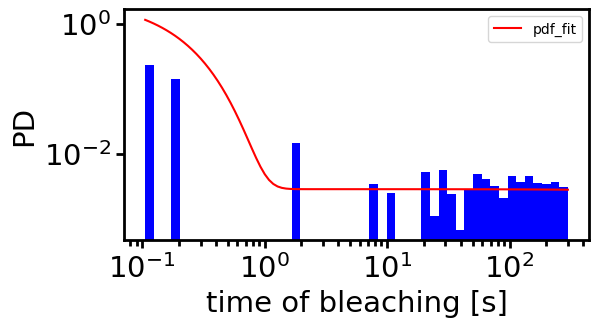

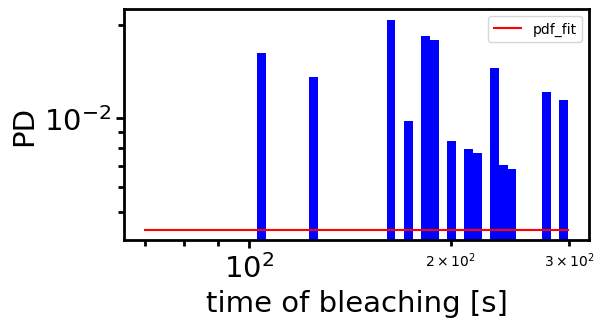

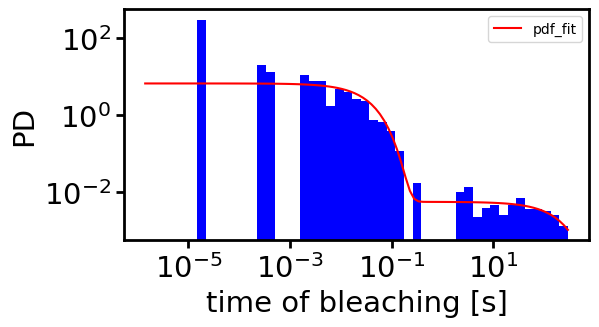

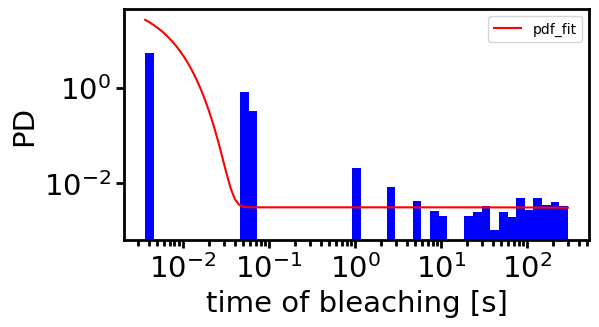

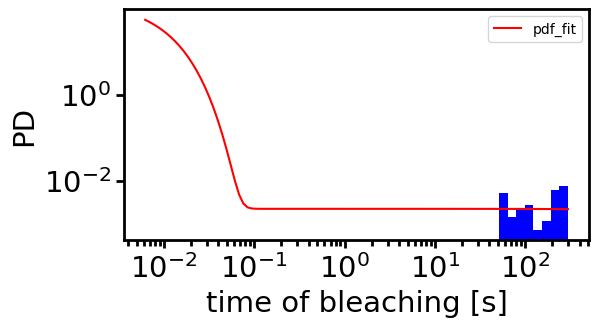

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 600x300 with 1 Axes>

In [4]:
for (bl_times, parameters_1) in zip(bleaching_times_all, parameters_all_fit_pdf):
    for i in range(bl_times.shape[1]):
        pi_fit_1, lambda1_fit_1, lambda2_fit_1 = parameters_1[i]
        #pi_fit_2, lambda1_fit_2, lambda2_fit_2 = parameters_2[i]
        data = bl_times[:, i][~np.isnan(bl_times[:, i])]
        bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
        ax = fi.universal_figure(type_='hist', bins=bins, data=data, density=True) 
        x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 100)
        # fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_2, lambda2_fit_2, pi_fit_2)], 
        #                     axes=ax[0], color='orange', label='cdf_fit')
        fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_1, lambda2_fit_1, pi_fit_1)], 
                            type_='line', axes=ax[0], yscale='log', xscale='log', 
                            xlabel='time of bleaching [s]', ylabel='PD', color='red', label='pdf_fit', legend=True)

In [16]:
parameters_all_fit_pdf

[[[0.005624041482487347, 1330.5761376859432, 5.939389835780024],
  [0.9999552003807377, 2.206850975128578, 130.04647716540273],
  [0.3407652480072196, 0.016185065305678585, 1.6054139256463997],
  [0.0420041191196254, 1.8344615106451239, 0.0016188574598447953]],
 [[0.9242278150991226, 5.5561195435341375, 0.06364558563059565],
  [0.527795421411815, 0.02595348092578773, 3.1100577285293114],
  [0.9111326359308145, 0.004930936275153742, 2.101266126370486],
  [0.9836881127385932, 6.416764321367537e-05, 2.467475787726268]],
 [[0.5200587432809316, 0.026990670303129335, 10.061823014800558],
  [0.8940312862480491, 0.006940389346948249, 5.591890618215751],
  [0.992285684995163, 6.415383207253778e-05, 7.092282524734088],
  [0.9999338930386481, 3.296911113678656e-09, 85459.45141607121]],
 [[0.8189858214696287, 0.005707440174398993, 31.31282539297835],
  [0.9944911951284371, 6.414045441941634e-05, 268.4669229705938],
  [0.9745252424283154, 6.416721434697676e-05, 161.03478040003063],
  [0.99993389303

In [17]:
from scipy.optimize import differential_evolution, LinearConstraint
from sklearn.metrics import r2_score


x_data = np.linspace(0, 300, 300001)
y_data = fingerprints_all[0].values

def objective_function(params):
    y_pred = dist.fit_4_fluorophore(x_data, *params)
    error = np.sum((y_data - y_pred) ** 2)

    return error

bounds = [(1, 500), (1, 500), (0.1, 100), (0.1, 100), (1e-2, 10), (1e-2, 10), (1e-4, 1), 
(1e-8, 1e-2), (0, 1), (0, 1), (0, 1), (0, 1)]

##### set up constraints

In [18]:
epsilon = 1e-3
linear_constraint1 = LinearConstraint(
    A=[[1, -1, 0, 0,  # lam1_1 > lam2_1 
        0, 0, 0, 0, 
        0, 0, 0, 0,],
        [0, 1, -1, 0,  # lam2_1 > lam3_1
        0, 0, 0, 0, 
        0, 0, 0, 0,],
        [0, 0, 1, -1,  # lam3_1 > lam4_1
        0, 0, 0, 0, 
        0, 0, 0, 0,],
        [1, 0, 0, 0, # lam1_1 > lam1_2
        -1, 0, 0, 0, 
        0, 0, 0, 0,],
        [0, 1, 0, 0, # lam2_1 > lam2_2
        0, -1, 0, 0, 
        0, 0, 0, 0,],
        [0, 0, 1, 0, # lam3_1 > lam3_2
        0, 0, -1, 0, 
        0, 0, 0, 0,],
        [0, 0, 0, 1, # lam4_1 > lam4_2
        0, 0, 0, -1, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # lam1_2 > lam2_2
        1, -1, 0, 0, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # lam2_2 > lam3_2
        0, 1, -1, 0, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # lam3_2 > lam4_2
        0, 0, 1, -1, 
        0, 0, 0, 0,],
        [0, 0, 0, 0, # p1 > p2
        0, 0, 0, 0, 
        1, -1, 0, 0,],
        [0, 0, 0, 0, # p2 > p3
        0, 0, 0, 0, 
        0, 1, -1, 0,],
        [0, 0, 0, 0, # p3 > p4
        0, 0, 0, 0, 
        0, 0, 1, -1,]], 
    lb=[epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon, epsilon], 
    ub=[float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf'), float('inf')])

In [ ]:
differential_evolution(objective_function, bounds=bounds, maxiter=1000, popsize=50, disp=True, constraints=linear_constraint1)

differential_evolution step 1: f(x)= 87.71156854583116
differential_evolution step 2: f(x)= 86.80460776263757
differential_evolution step 3: f(x)= 86.80460776263757
differential_evolution step 4: f(x)= 86.80460776263757
differential_evolution step 5: f(x)= 73.7531540913862
differential_evolution step 6: f(x)= 61.37754859951156
differential_evolution step 7: f(x)= 61.37754859951156
differential_evolution step 8: f(x)= 61.37754859951156
differential_evolution step 9: f(x)= 61.37754859951156
differential_evolution step 10: f(x)= 61.37754859951156
differential_evolution step 11: f(x)= 61.37754859951156
differential_evolution step 12: f(x)= 61.37754859951156
differential_evolution step 13: f(x)= 61.37754859951156
differential_evolution step 14: f(x)= 61.37754859951156
differential_evolution step 15: f(x)= 59.626195922707126
differential_evolution step 16: f(x)= 59.626195922707126
differential_evolution step 17: f(x)= 46.23791053378461
differential_evolution step 18: f(x)= 46.23791053378461


In [18]:
parameters_all

[array([[0.00000000e+00, 4.27199018e-02, 3.98280654e+00],
        [4.99539312e-02, 1.64581297e-01, 1.65491970e+00],
        [3.50146302e-01, 1.68847809e-02, 4.80320428e+00],
        [9.74116045e-01, 2.87599498e-04, 1.43799749e-02]]),
 array([[0.08740066, 0.26288073, 0.83733768],
        [0.47355681, 0.02690755, 4.83252614],
        [0.12897854, 0.00967802, 1.49957998],
        [0.21172906, 0.00875857, 1.49373793]]),
 array([[4.88639063e-01, 2.74453593e-02, 5.06758644e+00],
        [8.03243690e-01, 8.84367344e-03, 1.92016438e+01],
        [9.74116045e-01, 2.87599498e-04, 1.43799749e-02],
        [8.57708609e-01, 8.42028945e-03, 4.63176300e+01]]),
 array([[1.14977543e-01, 9.83358285e-03, 1.49988782e+00],
        [9.74116045e-01, 2.87599498e-04, 1.43799749e-02],
        [9.74116045e-01, 2.87599498e-04, 1.43799749e-02],
        [6.91804404e-02, 9.97574819e-01, 3.45902202e-01]])]

In [19]:
pis = []
lambdas1 = []
lambdas2 = []
for parameters in parameters_all[0]:
    min_i = np.argmin(parameters[1:])
    if min_i == 1:
        lambdas1.append(parameters[1])
        lambdas2.append(parameters[2])
        pis.append(parameters[0])
    else:
        lambdas1.append(parameters[2])
        lambdas2.append(parameters[1])
        pis.append(1-parameters[0])

In [20]:
pis

[1.0, 0.9500460687583273, 0.6498536975723785, 0.025883954794982733]

In [21]:
lambdas1

[3.98280654417095, 1.6549197003623797, 4.803204275195551, 0.014379974886101543]

In [28]:
lambdas2

[0.04271990175979995,
 0.1645812966107477,
 0.016884780874075276,
 0.0002875994977220315]

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

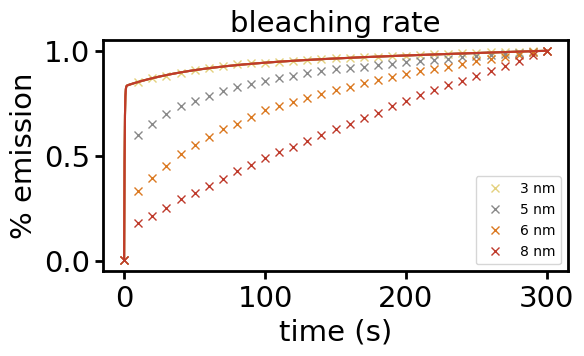

In [73]:
labels = ['3 nm', '5 nm', '6 nm', '8 nm']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 1000)
for (fingerprint, label, color) in zip(fingerprints_all, labels, colors):
    #pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.fit_4_fluorophore(x, 6.375, 5.155, 4.099, 3.722,
                                                        5.259, 4.976e-1, 0.02036, 0.000815,
                                                         1, 0.9989, 0.6637, 0.002325)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0])

array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

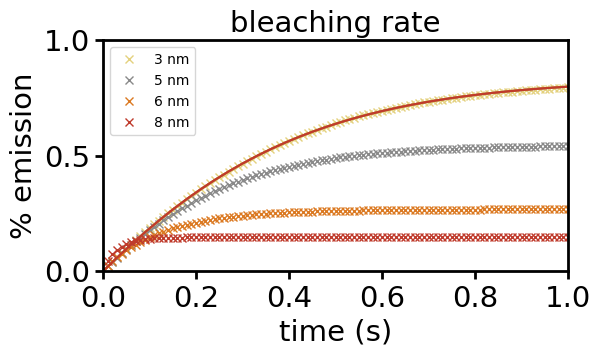

In [74]:
labels = ['3 nm', '5 nm', '6 nm', '8 nm']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 10000)
for (fingerprint, label, color) in zip(fingerprints_all, labels, colors):
    #pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10], fingerprint[::10]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10], fingerprint[::10]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    fi.universal_figure(data=[x, dist.fit_4_fluorophore(x, 6.375, 5.155, 4.099, 3.722,
                                                        5.259, 4.976e-1, 0.02036, 0.000815,
                                                         1, 0.9989, 0.6637, 0.002325)], axes=ax[0], color=color)
fi.universal_figure(title='bleaching rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0], xlim=[0, 1], ylim=[0, 1])

array([[<Axes: title={'center': '4F 3 nm fingerprint'}, xlabel='time (s)', ylabel='emissions (frac)'>]],
      dtype=object)

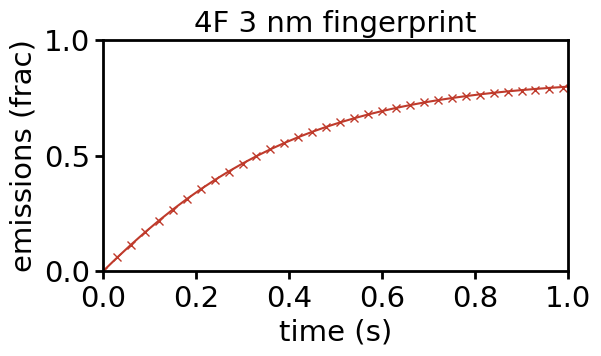

In [86]:
fingerprint = fingerprints_all[0]
ax = fi.universal_figure(data=[fingerprint.index[::30], fingerprint[::30]], color=color, marker='x', linestyle='')
fi.universal_figure(data=[x, dist.fit_4_fluorophore(x, 6.375, 5.155, 4.099, 3.722,
                                                        5.259, 4.976e-1, 0.02036, 0.000815,
                                                         1, 0.9989, 0.6637, 0.002325)], axes=ax[0], color=color)
fi.universal_figure(title='4F 3 nm fingerprint', ylabel='emissions (frac)', xlabel='time (s)', axes=ax[0], xlim=[0, 1], ylim=[0, 1])

array([[<Axes: title={'center': '4F 3 nm fingerprint'}, xlabel='time (s)', ylabel='emissions (frac)'>]],
      dtype=object)

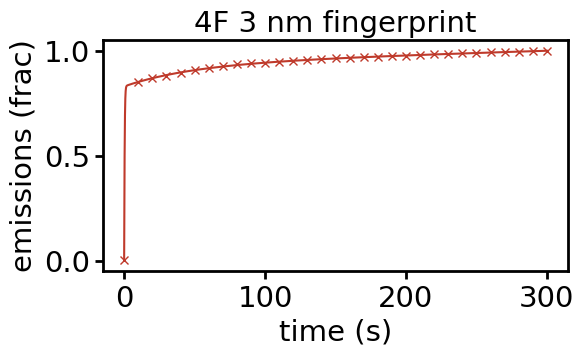

In [84]:
fingerprint = fingerprints_all[0]
ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], color=color, marker='x', linestyle='')
fi.universal_figure(data=[x, dist.fit_4_fluorophore(x, 6.375, 5.155, 4.099, 3.722,
                                                        5.259, 4.976e-1, 0.02036, 0.000815,
                                                         1, 0.9989, 0.6637, 0.002325)], axes=ax[0], color=color)
fi.universal_figure(title='4F 3 nm fingerprint', ylabel='emissions (frac)', xlabel='time (s)', axes=ax[0])